In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import sys

root_dir = Path.cwd().parent

if str(root_dir) not in sys.path:
    sys.path.insert(0, str(root_dir))

plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

PROJECT = Path.cwd().parent
PHASE3 = PROJECT / 'data' / 'phase3'
TAB = PROJECT / 'results' / 'phase3' / 'tables'
FIG = PROJECT / 'results' / 'phase3' / 'figures'

# Load summary
summary = pd.read_csv(TAB / 'phase3_summary.csv')
print(summary[['venue','spec','n_days','n_params','kl_mean','converged',
               'mean_c','c_low','c_mid','c_high']].to_string(index=False))

venue   spec  n_days  n_params   kl_mean  converged    mean_c     c_low    c_mid   c_high
  CME crypto     624        12 -0.239066       True -0.769005 -5.371087 1.971267 1.092806
  CME  macro     624        15 -0.232218      False  2.293687 -2.324977 2.620645 6.585392
  CME   full     624        24 -0.247319      False  2.501496  0.040916 3.836935 3.626637
  DER crypto     765        12 -0.200000       True  0.336831 -4.528587 2.694088 2.844990
  DER  macro     765        15 -0.196463      False  3.614983 -1.095837 4.219347 7.721438
  DER   full     765        24 -0.210818      False  3.850935  1.179146 4.339063 6.034597


#### 1. Estimation Diagnostics

Key checks: convergence status, KL mean (lower = better fit), and the curvature
coefficient $c_t$ (positive = hump in the kernel)

In [2]:
# Display full summary with formatting
display_cols = ['venue', 'spec', 'converged', 'kl_mean',
                'mean_b', 'std_b', 'mean_c', 'std_c', 'mean_d', 'std_d',
                'c_low', 'c_mid', 'c_high']
print(summary[display_cols].round(4).to_string(index=False))

venue   spec  converged  kl_mean  mean_b   std_b  mean_c   std_c  mean_d  std_d   c_low  c_mid  c_high
  CME crypto       True  -0.2391  8.9769 13.5138 -0.7690 12.0944 -2.7172 3.7590 -5.3711 1.9713  1.0928
  CME  macro      False  -0.2322  5.9217 14.1705  2.2937 16.4522 -3.7319 6.2711 -2.3250 2.6206  6.5854
  CME   full      False  -0.2473  6.1394 15.1353  2.5015 15.0108 -3.9191 5.3480  0.0409 3.8369  3.6266
  DER crypto       True  -0.2000  6.8029 12.6183  0.3368 11.0412 -2.7528 3.3555 -4.5286 2.6941  2.8450
  DER  macro      False  -0.1965  3.6051 13.1942  3.6150 15.3169 -3.8599 5.9071 -1.0958 4.2193  7.7214
  DER   full      False  -0.2108  3.8556 12.6685  3.8509 12.7932 -4.0742 4.7950  1.1791 4.3391  6.0346


#### 2. Kernel at Volatility Terciles 

For the crypto specification (converged on both venues), compare how the kernel
shape changes across low/mid/high volatility regimes. The hump (c > 0) should be
more pronounced in low-vol regimes per Almeida et al.

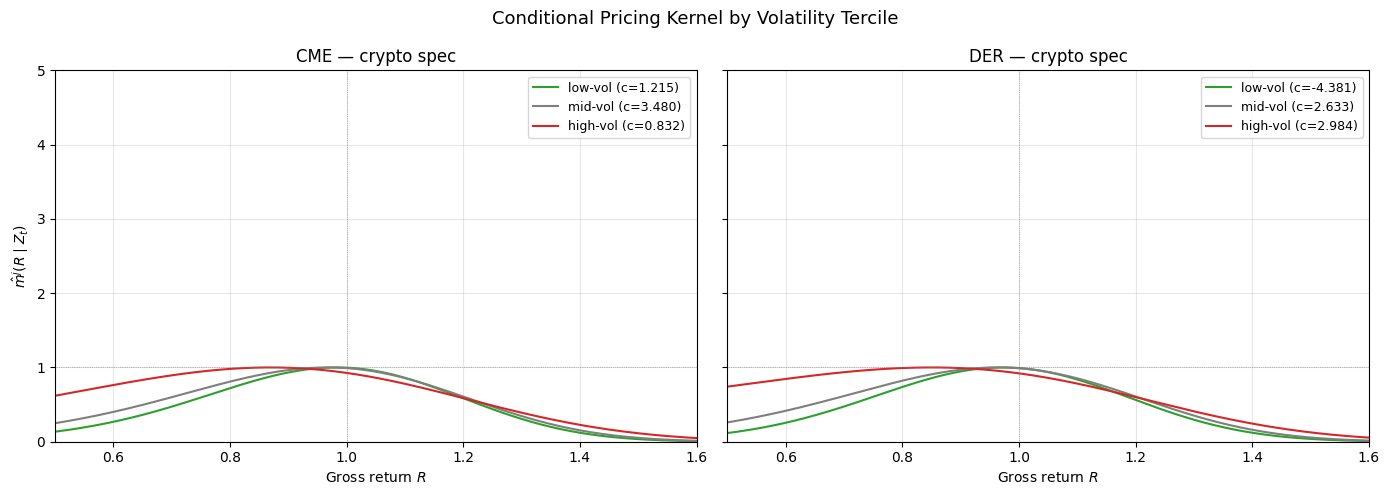

In [3]:
from src.pricing_kernel.conditional_kernel import (
    ConditionalKernelResult, evaluate_kernel_at_terciles
)

from src.config import get_return_grid
R_GRID = get_return_grid()
colors = {'low': 'C2', 'mid': 'C7', 'high': 'C3'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, venue in zip(axes, ['CME', 'DER']):
    key = f'{venue}_crypto'
    data = np.load(PHASE3 / f'phase3_{key}.npz', allow_pickle=True)

    # Reconstruct the result from saved npz (need theta and n_Z)
    row = summary[(summary['venue']==venue) & (summary['spec']=='crypto')].iloc[0]
    n_Z = 3  # crypto has 3 vars

    # Load Z_crypto for tercile evaluation
    Z_crypto = pd.read_parquet(PROJECT / 'data' / 'conditioning' / 'Z_crypto.parquet')
    z_cols = [c for c in Z_crypto.columns if c != 'date' and not c.endswith('_raw')]
    Z_mat = Z_crypto[z_cols].values[:int(row['n_days'])]

    result = ConditionalKernelResult(
        theta=data['theta'], n_params=int(row['n_params']),
        n_days=int(row['n_days']), n_Z=n_Z, venue=venue,
        spec_name='crypto', kl_total=row['kl_total'],
        kl_mean=row['kl_mean'], converged=row['converged'],
        hessian_inv=None
    )
    terciles = evaluate_kernel_at_terciles(result, R_GRID, Z_mat)

    for name in ['low', 'mid', 'high']:
        if name not in terciles:
            continue
        t = terciles[name]
        ax.plot(R_GRID, t['kernel'], color=colors[name], lw=1.5,
                label=f"{name}-vol (c={t['c']:.3f})")
    ax.axhline(1.0, color='gray', lw=0.5, ls=':')
    ax.axvline(1.0, color='gray', lw=0.5, ls=':')
    ax.set_xlabel('Gross return $R$')
    ax.set_xlim(0.5, 1.6)
    ax.set_ylim(0, 5)
    ax.set_title(f'{venue} — crypto spec')
    ax.legend(fontsize=9)

axes[0].set_ylabel(r'$\hat{m}^j(R \mid Z_t)$')
fig.suptitle('Conditional Pricing Kernel by Volatility Tercile', fontsize=13)
plt.tight_layout()
plt.show()

#### 3. Coefficient Time Series (crypto spec)

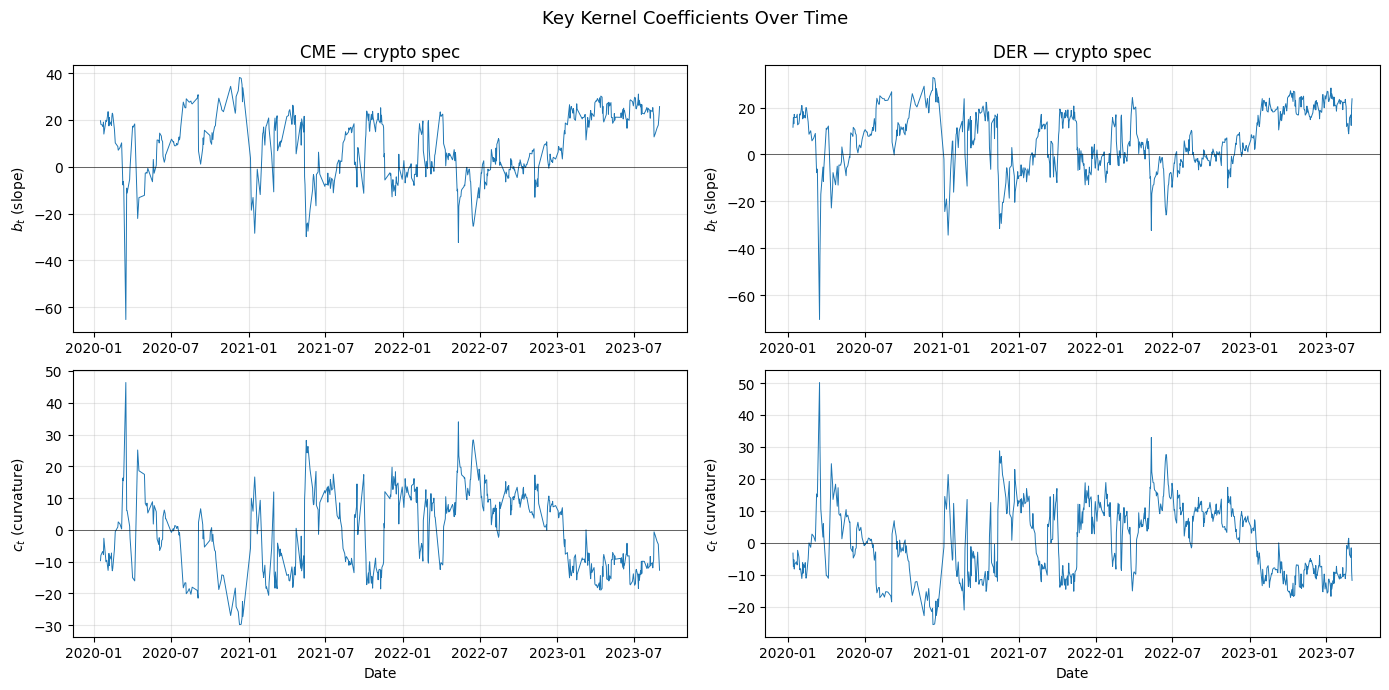

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 7))
for venue, col_offset in [('CME', 0), ('DER', 1)]:
    data = np.load(PHASE3 / f'phase3_{venue}_crypto.npz', allow_pickle=True)
    dates = pd.to_datetime(data['dates'])
    for row_idx, (coeff, label) in enumerate([
        ('coeffs_b', '$b_t$ (slope)'), ('coeffs_c', '$c_t$ (curvature)')
    ]):
        ax = axes[row_idx, col_offset]
        ax.plot(dates, data[coeff], lw=0.7, color='C0')
        ax.axhline(0, color='black', lw=0.4)
        ax.set_ylabel(label)
        if row_idx == 0:
            ax.set_title(f'{venue} — crypto spec')

for ax in axes[-1]:
    ax.set_xlabel('Date')
plt.suptitle('Key Kernel Coefficients Over Time', fontsize=13)
plt.tight_layout()
plt.show()

#### 4. Unconditional Microstructure Friction Kernel

$\Psi(R) = \log(\hat{q}^{\mathrm{CME}}(R) / \hat{q}^{\mathrm{DER}}(R))$.
Positive values mean CME prices that return state more expensively than Deribit

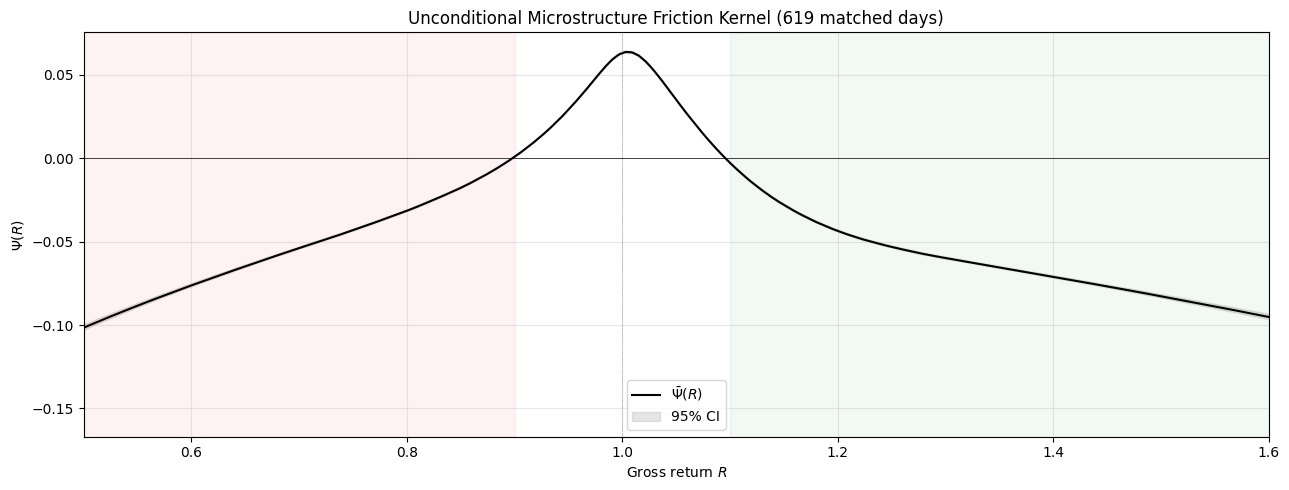

In [5]:
mfk = np.load(PHASE3 / 'mfk_unconditional.npz')
R_mfk = mfk['R_grid']
psi = mfk['mfk_mean']
psi_se = mfk['mfk_std'] / np.sqrt(mfk['n_days'])

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(R_mfk, psi, 'k-', lw=1.5, label=r'$\bar{\Psi}(R)$')
ax.fill_between(R_mfk, psi - 1.96*psi_se, psi + 1.96*psi_se,
                alpha=0.2, color='gray', label='95% CI')
ax.axhline(0, color='black', lw=0.5)
ax.axvline(1.0, color='gray', lw=0.5, ls=':')
ax.axvspan(R_mfk[0], 0.90, alpha=0.05, color='red')
ax.axvspan(1.10, R_mfk[-1], alpha=0.05, color='green')
ax.set_xlabel('Gross return $R$')
ax.set_ylabel(r'$\Psi(R)$')
ax.set_xlim(0.5, 1.6)
ax.set_title(f'Unconditional Microstructure Friction Kernel ({int(mfk["n_days"])} matched days)')
ax.legend()
plt.tight_layout()
plt.show()

#### 5. Specification Comparison: KL Fit Quality

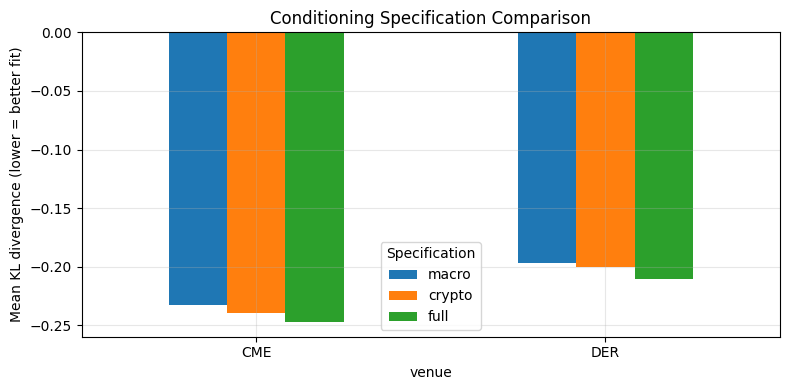


Convergence status:
spec   crypto   full  macro
venue                      
CME      True  False  False
DER      True  False  False


In [6]:
kl_pivot = summary.pivot(index='venue', columns='spec', values='kl_mean')
kl_pivot = kl_pivot[['macro', 'crypto', 'full']]

fig, ax = plt.subplots(figsize=(8, 4))
kl_pivot.plot(kind='bar', ax=ax)
ax.set_ylabel('Mean KL divergence (lower = better fit)')
ax.set_title('Conditioning Specification Comparison')
ax.legend(title='Specification')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print('\nConvergence status:')
print(summary.pivot(index='venue', columns='spec', values='converged').to_string())